### Final Graphs

In [1]:
import pandas as pd
import re
import nltk
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

In [8]:
### DataFrame and Graphs Settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colum', None)
pd.set_option("display.max_colwidth", None)

sns.set(font_scale=1.5)
sns.set(style='white', font_scale=1.5)

#### Time Series

In [2]:
df_aux= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/year.csv.zip', delimiter=',', header=0)
df_aux=df_aux[(df_aux.year < 2022) ]
df_aux['main_ratio']=df_aux['main']/df_aux['length']
df_temp=df_aux.groupby('year').mean().reset_index()

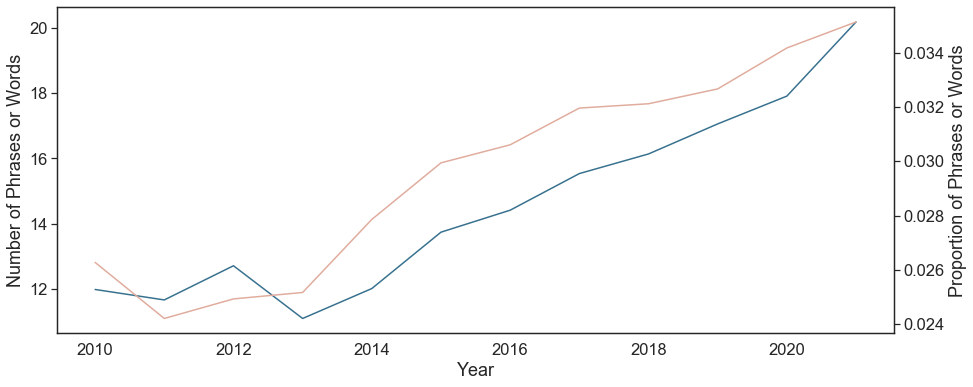

In [52]:
fig, ax = plt.subplots(figsize=(15, 6))
ax2=ax.twinx()
ax.plot(df_temp.year, df_temp.main,color="#37718E" )
ax2.plot(df_temp.year, df_temp.main_ratio, color='#E0AC9D')



ax.set_xlabel('Year')
ax.set_ylabel('Number of Phrases or Words')
ax2.set_ylabel('Proportion of Phrases or Words')


plt.savefig('time_words.pdf', bbox_inches='tight')

#### Distributions

In [25]:
### Within MSA
df_msa=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/dist_tot_msa.csv.zip', delimiter=',', header=0)
df_msa=df_msa[(df_msa.MSA_ != -999.0)]

In [29]:
### Within Firms
df_firm=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/dist_tot_emp.csv.zip', delimiter=',', header=0)

In [56]:
df_firm=df_firm[(df_firm.main_count != 1)] 

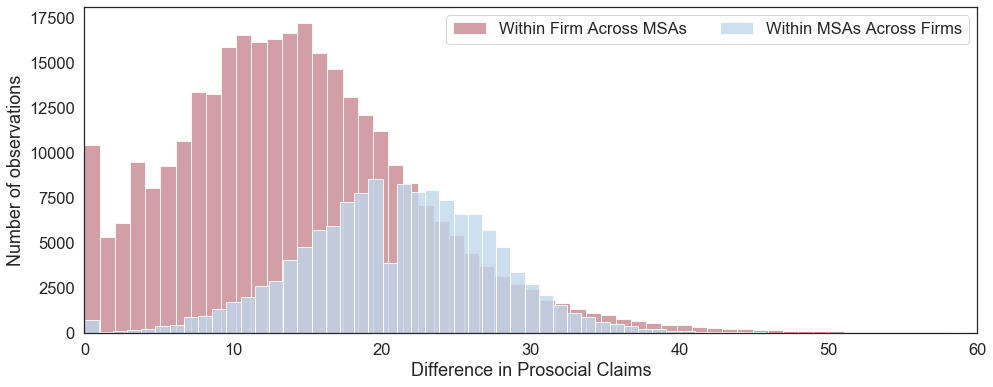

In [74]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_firm['main_per_90']-df_firm['main_per_10'], bins=500,  color='#C6878F', alpha=.8, label='Within Firm Across MSAs')
ax.hist(df_msa['main_per_90']-df_msa['main_per_10'], bins=200,  color='#BFD7EA', alpha=.8, label='Within MSAs Across Firms')
ax.legend(loc='upper right', fancybox=True, ncol=3)


ax.set_ylabel('Number of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,60])
plt.savefig('diff_within_firm.pdf', bbox_inches='tight')

In [54]:
### Occupation 
df_occ=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/dist_tot_occ.csv.zip', delimiter=',', header=0)


In [58]:
df_occ=df_occ[(df_occ.main_count != 1)] 

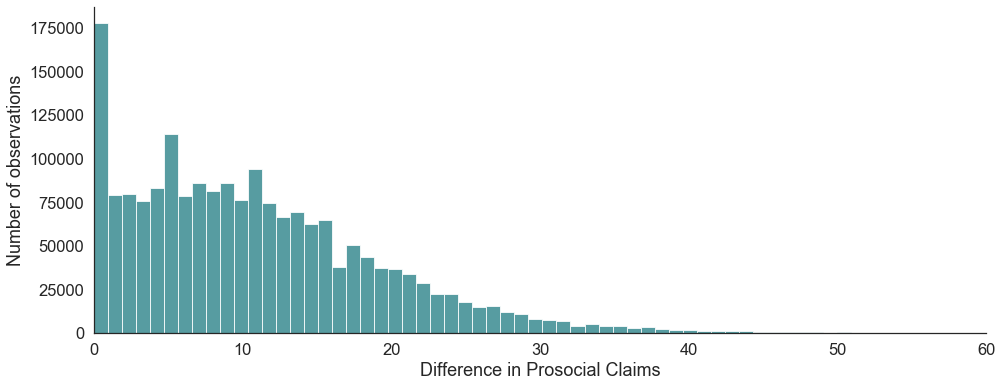

In [75]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_occ['main_per_90']-df_occ['main_per_10'], bins=600,  color='#2D848A', alpha=.8)


ax.set_ylabel('Number of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,60])
#ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims  within Firms and Occupations, Across MSAs  ')

sns.despine()
plt.savefig('occ_firm_diff.pdf', bbox_inches='tight')